# Companion mismatch in the component-letter variant rule

- The ID variant rule strips a trailing component letter from SIMBAD IDs: `GJ 86 B` -> `GJ 86`.
- This can attach a planet to a companion star instead of its true host.
- Questions: how often does that actually happen, and how many ID matches are lost if the rule is removed?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from astropy.table import Table

from crossmatching import Crossmatcher, NEACatalog, EMCCatalog, SimbadIdSupplier, EMCIdSupplier

HPIC_FILE    = "tests/data/HPIC_LC4_combined_d50_20260611.txt"
ALT_IDS_FILE = "tests/data/alternate_ids_hpic_20260611.txt"
NEA_FILE     = "tests/data/pscomppars_20260611.txt"
EMC_FILE     = "exo-mercat.csv"

def norm(s):
    return " ".join(str(s).split())

input_table = Table.read(HPIC_FILE, format="ascii")
name_list = input_table["star_name"].tolist()
print(f"{len(input_table)} input stars")

14571 input stars


## ID matches with and without the rule, per catalog x supplier config

- The rule is disabled via a supplier subclass that filters out the component variant.

In [2]:
COMPONENT_LETTERS = "ABCSN"

def component_variant(id_str):
    """The variant the component-letter rule would produce, or None."""
    id_str = id_str.strip()
    if len(id_str) > 2 and id_str[-2] == " " and id_str[-1] in COMPONENT_LETTERS:
        return id_str[:-2]
    return None

def without_component_rule(supplier_cls):
    class NoComponentRule(supplier_cls):
        def id_variants(self, id_str):
            excluded = component_variant(id_str)
            return [v for v in super().id_variants(id_str) if v != excluded]
    return NoComponentRule

CONFIGS = [
    ("nea-simbad", NEACatalog, SimbadIdSupplier, NEA_FILE, "ascii", ALT_IDS_FILE),
    ("emc-simbad", EMCCatalog, SimbadIdSupplier, EMC_FILE, "csv",   ALT_IDS_FILE),
    ("emc-emc",    EMCCatalog, EMCIdSupplier,    EMC_FILE, "csv",   EMC_FILE),
]

def run_config(catalog_cls, supplier_cls, cat_file, cat_format, alt_file):
    cm = Crossmatcher(catalog_cls(), supplier_cls())
    cm.load_catalog(from_file=cat_file, format=cat_format)
    cm.load_alternate_ids(name_list, from_file=alt_file)
    matched = cm.id_crossmatch(input_table, "star_name", ra_key="ra", dec_key="dec")
    pairs = {(norm(s), norm(p)) for s, p in zip(matched["star_name"], matched[cm.planet_uid])}
    return cm, matched, pairs

results = {}
for label, cat_cls, sup_cls, cat_file, cat_fmt, alt_file in CONFIGS:
    cm, matched, pairs = run_config(cat_cls, sup_cls, cat_file, cat_fmt, alt_file)
    _, _, pairs_norule = run_config(cat_cls, without_component_rule(sup_cls), cat_file, cat_fmt, alt_file)
    results[label] = dict(cm=cm, matched=matched, pairs=pairs,
                          pairs_norule=pairs_norule, rule_only=pairs - pairs_norule)

Table(rows=[(label, len(r["pairs"]), len(r["pairs_norule"]), len(r["rule_only"]))
            for label, r in results.items()],
      names=["config", "id matches (with rule)", "without rule", "lost without rule"])

config,id matches (with rule),without rule,lost without rule
str10,int64,int64,int64
nea-simbad,806,806,0
emc-simbad,1119,1079,40
emc-emc,1216,1216,0


## Why only emc-simbad is affected

- EMC host names are system-level (`GJ 777`), while SIMBAD IDs are component-level (`GJ 777 A`); the rule bridges that gap.
- NEA host names always coincide with another SIMBAD ID of the star, so the rule adds nothing there.
- All further analysis uses the emc-simbad rule-only matches.

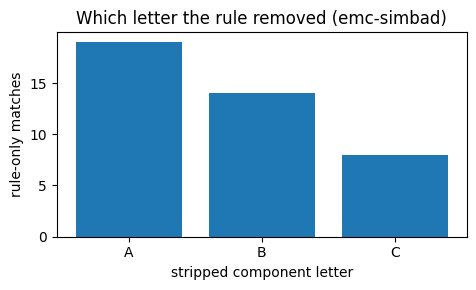

In [3]:
res = results["emc-simbad"]
cm, matched, rule_only = res["cm"], res["matched"], res["rule_only"]
host_of_planet = {norm(r[cm.planet_uid]): norm(r[cm.catalog.host_key]) for r in cm.catalog_table}

raw = SimbadIdSupplier().load_raw(ALT_IDS_FILE)
raw_ids_by_star = {}
for row in raw:
    star = norm(row["input_ids"])
    tokens = [t.strip() for t in str(row["ids"]).split("|")]
    raw_ids_by_star.setdefault(star, []).extend(t for t in tokens if t and t != "--")

def firing_ids(star, host):
    """Raw SIMBAD IDs of star whose component-stripped form equals host."""
    return [r for r in raw_ids_by_star.get(star, [])
            if component_variant(r) is not None and norm(component_variant(r)) == host]

record_set = set()
for star, planet in rule_only:
    host = host_of_planet[planet]
    for raw_id in firing_ids(star, host):
        record_set.add((star, planet, host, raw_id, raw_id[-1]))
records = Table(rows=sorted(record_set),
                names=["star_name", "planet", "host", "raw_id", "letter"])

letters, counts = np.unique(records["letter"], return_counts=True)
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(letters, counts, color="tab:blue")
ax.set_xlabel("stripped component letter")
ax.set_ylabel("rule-only matches")
ax.set_title("Which letter the rule removed (emc-simbad)")
plt.tight_layout()
plt.show()

## Is the rule-only match pointing at the right star?

- Adjudicate with the coordinate crossmatch: planet assigned to the same star = agree, different star = companion mismatch.
- Also flag planets that get attached to two different input stars by the ID step.
- Caveat: nearest-star coordinate matching can itself pick a close companion, so this is approximate.

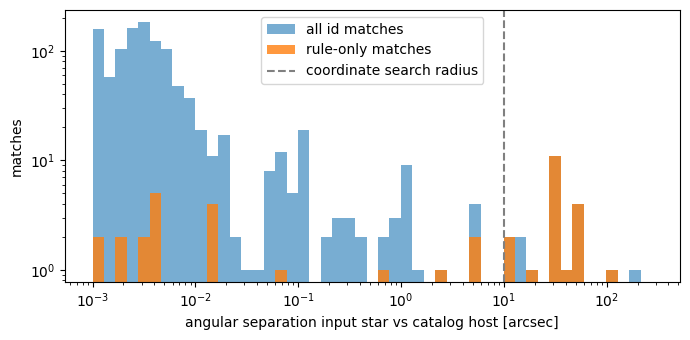

In [4]:
coord_matched = cm.coordinate_crossmatch(input_table, "star_name")
coord_star_of_planet = {norm(r[cm.planet_uid]): norm(r["star_name"]) for r in coord_matched}

stars_n   = [norm(s) for s in matched["star_name"]]
planets_n = [norm(p) for p in matched[cm.planet_uid]]
seps      = np.ma.filled(np.ma.asarray(matched[cm.angular_sep_key]), np.nan).astype(float)

sep_of_pair = {}
for s, p, sep in zip(stars_n, planets_n, seps):
    if np.isfinite(sep):
        sep_of_pair[(s, p)] = min(float(sep), sep_of_pair.get((s, p), np.inf))

def classify(star, planet):
    coord_star = coord_star_of_planet.get(planet)
    if coord_star == star:
        return "same star"
    if coord_star is not None:
        return "different star"
    return "no coord match"

pair_class = {(s, p): classify(s, p) for s, p in rule_only}

all_seps = np.clip([v for v in sep_of_pair.values()], 1e-3, None)
ro_seps  = np.clip([sep_of_pair[pair] for pair in rule_only if pair in sep_of_pair], 1e-3, None)
bins = np.geomspace(1e-3, max(np.max(all_seps), 10) * 1.5, 50)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(all_seps, bins=bins, alpha=0.6, label="all id matches")
ax.hist(ro_seps, bins=bins, alpha=0.8, label="rule-only matches")
ax.axvline(10, ls="--", color="gray", label="coordinate search radius")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("angular separation input star vs catalog host [arcsec]")
ax.set_ylabel("matches")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
class_counts = Counter(pair_class.values())
for label in ("same star", "different star", "no coord match"):
    print(f"{label:15s}: {class_counts.get(label, 0)}")

stars_of_planet = defaultdict(set)
for s, p in res["pairs"]:
    stars_of_planet[p].add(s)
dup_planets = sorted(p for p, ss in stars_of_planet.items()
                     if len(ss) > 1 and any((s, p) in rule_only for s in ss))
print(f"\nplanets attached to >1 input star (rule involved): {len(dup_planets)}")

mismatches = sorted(pair for pair, c in pair_class.items() if c == "different star")
rows = [(s, p, host_of_planet[p], coord_star_of_planet[p],
         round(sep_of_pair.get((s, p), np.nan), 2)) for s, p in mismatches]
Table(rows=rows, names=["matched star", "planet", "catalog host",
                        "coord-matched star", "sep [arcsec]"]) if rows else print("no mismatches")

same star      : 17
different star : 23
no coord match : 0

planets attached to >1 input star (rule involved): 21


matched star,planet,catalog host,coord-matched star,sep [arcsec]
str13,str15,str6,str13,float64
TIC 123013596,BD+45 2743 A b,GJ 720,TIC 122958010,112.11
TIC 154385809,HD 156384 C b,GJ 667,TIC 154385728,32.65
TIC 154385809,HD 156384 C c,GJ 667,TIC 154385728,32.65
TIC 154385809,HD 156384 C d,GJ 667,TIC 154385728,32.65
TIC 154385809,HD 156384 C e,GJ 667,TIC 154385728,32.65
TIC 154385809,HD 156384 C f,GJ 667,TIC 154385728,32.65
TIC 154385809,HD 156384 C g,GJ 667,TIC 154385728,32.65
TIC 154385809,HD 156384 C h,GJ 667,TIC 154385728,32.65
TIC 247985093,BD+19 5116 A b,GJ 896,TIC 247985094,5.04


## Sharper adjudication: fired letter vs letter in the planet name

- EMC planet names often carry the true component: `BD+45 2743 A b` orbits the A component.
- If the star's fired letter equals the planet-name letter, the ID match points at the right component and the coordinate adjudication (system-level EMC coordinates, usually on the primary) is the misleading one.
- If the letters disagree, it is a genuine companion mismatch.

In [6]:
def planet_component_letter(planet):
    """Component letter embedded in an EMC planet name, or None."""
    tokens = planet.split()
    if len(tokens) >= 3 and len(tokens[-2]) == 1 and tokens[-2] in COMPONENT_LETTERS:
        return tokens[-2]
    return None

def letter_verdict(star, planet):
    pl_letter = planet_component_letter(planet)
    fired = {r[-1] for r in firing_ids(star, host_of_planet[planet])}
    if pl_letter is None:
        return "no letter in planet name"
    return "letters agree" if pl_letter in fired else "letters disagree (mismatch)"

verdicts = {pair: letter_verdict(*pair) for pair in rule_only}

crosstab = Counter((pair_class[pair], verdicts[pair]) for pair in rule_only)
print(f"{'coordinate adjudication':25s} {'letter adjudication':30s} pairs")
for (coord_c, letter_c), n in sorted(crosstab.items()):
    print(f"{coord_c:25s} {letter_c:30s} {n}")

genuine_mismatch = sorted(pair for pair, v in verdicts.items() if v == "letters disagree (mismatch)")
print(f"\ngenuine companion mismatches (letters disagree): {len(genuine_mismatch)}")
for s, p in genuine_mismatch:
    print(f"  {s}  fired {sorted({r[-1] for r in firing_ids(s, host_of_planet[p])})}"
          f"  but planet is {p}")

coordinate adjudication   letter adjudication            pairs
different star            letters agree                  7
different star            letters disagree (mismatch)    15
different star            no letter in planet name       1
same star                 letters agree                  17

genuine companion mismatches (letters disagree): 15
  TIC 123013596  fired ['B']  but planet is BD+45 2743 A b
  TIC 247985093  fired ['B']  but planet is BD+19 5116 A b
  TIC 251078595  fired ['A']  but planet is HD 79211 B b
  TIC 298434278  fired ['B']  but planet is BD+24 2733 A b
  TIC 359676790  fired ['A']  but planet is HD 173740 B b
  TIC 359676790  fired ['A']  but planet is HD 173740 B c
  TIC 369021290  fired ['B']  but planet is CD-51 10924 A b
  TIC 369021290  fired ['B']  but planet is CD-51 10924 A c
  TIC 369021290  fired ['B']  but planet is CD-51 10924 A d
  TIC 369021290  fired ['B']  but planet is CD-51 10924 A e
  TIC 420470817  fired ['A', 'C']  but planet is BD+66 3

## Mechanism, concrete case

- Walk through the chain of the worst (largest separation) companion mismatch.

In [7]:
candidates = mismatches or sorted(rule_only)
star, planet = max(candidates, key=lambda pair: sep_of_pair.get(pair, 0))
host = host_of_planet[planet]
firing = firing_ids(star, host)
rival = coord_star_of_planet.get(planet)

print(f"input star          : {star}")
print(f"firing SIMBAD id(s) : {firing}")
print(f"stripped variant    : {[component_variant(r) for r in firing]}")
print(f"catalog host        : {host}")
print(f"planet              : {planet}")
print(f"id-match separation : {sep_of_pair.get((star, planet), np.nan):.2f} arcsec")
print(f"coordinates assign planet to: {rival}")
if rival is not None and rival != star:
    print(f"rival star ids matching host: {firing_ids(rival, host)} "
          f"+ direct: {[r for r in raw_ids_by_star.get(rival, []) if norm(r) == host]}")

input star          : TIC 123013596
firing SIMBAD id(s) : ['GJ 720 B']
stripped variant    : ['GJ 720']
catalog host        : GJ 720
planet              : BD+45 2743 A b
id-match separation : 112.11 arcsec
coordinates assign planet to: TIC 122958010
rival star ids matching host: ['GJ 720 A'] + direct: []


## Conclusions

- The rule only matters for emc-simbad: 40 of 1119 ID matches (3.6%) exist only through it. nea-simbad and emc-emc lose nothing without it.
- Reason: EMC host names are system-level (`GJ 720`), SIMBAD IDs are component-level (`GJ 720 A`/`B`). NEA host names always coincide with another SIMBAD ID directly.
- Of the 40 rule-only matches: 24 point at the right component (17 confirmed by coordinates, 7 by the planet-name letter), 15 are genuine companion mismatches, 1 is ambiguous.
- Mismatch mechanism: both binary components are separate HPIC entries, each with a lettered SIMBAD ID. Both strip to the same system-level host, so the planet attaches to both stars (21 planets end up on >1 star).
- Removing the rule is not a clean fix: it drops the 15 mismatches but also the 24 correct matches that have no other ID route (`GJ 720 A` has no bare `GJ 720` ID).
- Possible refinement: when the planet name carries a component letter, require the fired letter to agree. That removes all 15 mismatches and keeps every correct match.